## Полносвязные нейронные сети (FCNN). Решение задачи регрессии 

In [3]:
import pandas as pd
import optuna
import joblib
#import tensorflow as tf
import warnings

from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_predict, train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.neural_network import MLPRegressor

In [2]:
import tensorflow as tf

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Чтение данных

In [4]:
data = pd.read_csv("../data/diamonds_filtered.csv")
data.head(10)

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190
5,0.30,5,2,2,62.0,54,348,2.155
6,0.30,2,1,3,63.4,54,351,2.115
7,0.30,2,1,3,63.8,56,351,2.115
8,0.30,3,1,3,62.7,59,351,2.105
9,0.30,2,2,2,63.3,56,351,2.130


### Выделение целевого признака и предиктора

In [5]:
y = data['price']
x = data.drop('price', axis=1)

### Оптимизация признакового пространства

In [6]:
skb = SelectKBest(k=4)
x_skb = skb.fit_transform(x, y)

### MLPRegressor

In [5]:
def print_mlp_architecture(pipeline):
    mlp = pipeline.named_steps['mlp']
    print(f"Входных признаков: {mlp.n_features_in_}")
    print(f"Скрытые слои: {mlp.hidden_layer_sizes}")
    print(f"Количество слоев (всего): {mlp.n_layers_}")
    print(f"Выходной слой: {mlp.n_outputs_}")
    print(f"Функция активации: {mlp.activation}")
    print(f"Оптимизатор: {mlp.solver}")

def plot_learning_curves(pipeline, title="Обучение модели"):
    mlp = pipeline.named_steps['mlp']
    
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(mlp.loss_curve_, label='Training Loss', color='blue', lw=2)
    ax1.set_xlabel('Эпохи (итерации)')
    ax1.set_ylabel('Loss (MSE)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    if hasattr(mlp, 'validation_scores_'):
        ax2 = ax1.twinx()
        ax2.plot(mlp.validation_scores_, label='Validation $R^2$', color='red', lw=2)
        ax2.set_ylabel('Score ($R^2$)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title(title)
    fig.tight_layout()
    plt.show()

R^2 = 0.9719


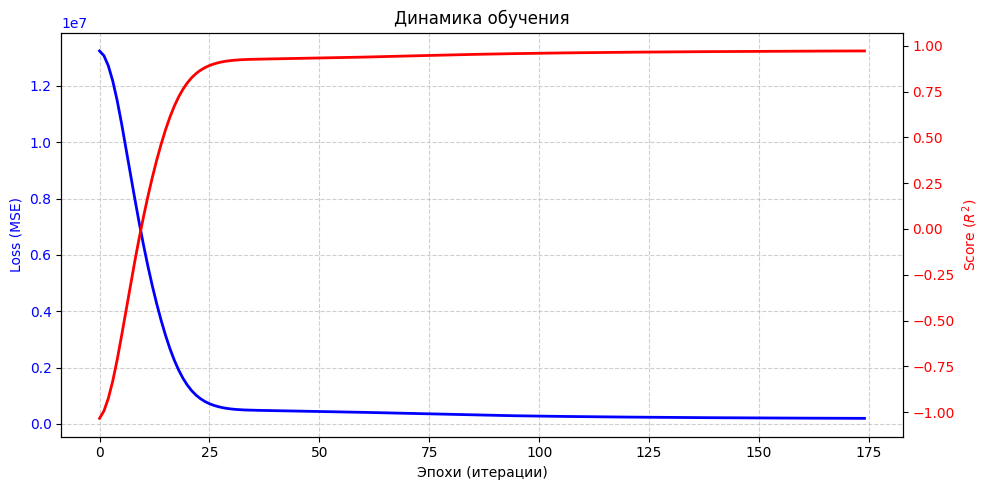

In [7]:
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(early_stopping=True, max_iter=1000))
])

base_kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred_base = cross_val_predict(base_pipeline, x_skb, y, cv=base_kf, n_jobs=-1)
r2_base = r2_score(y, y_pred_base)
print(f"R^2 = {round(r2_base, 4)}")

base_pipeline.fit(x_skb, y)

plot_learning_curves(base_pipeline, title="Динамика обучения")

In [21]:
print_mlp_architecture(pipeline=base_pipeline)

Входных признаков: 4
Скрытые слои: (100,)
Количество слоев (всего): 3
Выходной слой: 1
Функция активации: relu
Оптимизатор: adam


In [22]:
joblib.dump(base_pipeline, '../models/base_mlp_optuna.pkl')

['../models/base_mlp_optuna.pkl']

### MLPRegressor с Optuna

In [17]:
def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical(
            'hidden_layer_sizes', 
            [(50,), (100,), (100, 50), (150, 100)] 
        ),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-4, 1e-2, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-3, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 'auto']), 
    }
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            **params,
            solver='adam', 
            random_state=81,
            early_stopping=True,
            max_iter=400,          
            n_iter_no_change=10,   
            validation_fraction=0.1
        ))
    ])

    cv = KFold(n_splits=3, shuffle=True, random_state=81) 
    
    scores = cross_val_score(
        pipeline, 
        x_skb, 
        y, 
        cv=cv, 
        scoring='r2',
        n_jobs=-1 
    )
    
    return scores.mean()

In [18]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-05-04 18:55:34,765] A new study created in memory with name: no-name-edab9080-934a-4a98-b735-5f60eb0d72e6


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-04 18:55:44,321] Trial 0 finished with value: 0.9783404800221861 and parameters: {'hidden_layer_sizes': (150, 100), 'activation': 'relu', 'alpha': 0.0007504967175621064, 'learning_rate_init': 0.0012512509566270126, 'batch_size': 'auto'}. Best is trial 0 with value: 0.9783404800221861.


/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2026-05-04 18:55:51,445] Trial 1 finished with value: 0.5156025560289118 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'tanh', 'alpha': 0.00046164626835024634, 'learning_rate_init': 0.0017397178608073724, 'batch_size': 'auto'}. Best is trial 0 with value: 0.9783404800221861.


...

[I 2026-05-04 19:01:23,897] Trial 36 finished with value: 0.8892556250895486 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0002975749669302248, 'learning_rate_init': 0.0010959312969359071, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:01:32,510] Trial 37 finished with value: 0.9797370349524431 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0006813442687642745, 'learning_rate_init': 0.0045438848578399265, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.


/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2026-05-04 19:01:40,697] Trial 38 finished with value: 0.9742623693311806 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'tanh', 'alpha': 0.0002180988107880019, 'learning_rate_init': 0.0036405860110687036, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:01:52,760] Trial 39 finished with value: 0.978712105995977 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0009665506537392521, 'learning_rate_init': 0.002538229801157686, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:02:01,489] Trial 40 finished with value: 0.9797123468210467 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0004993859257378865, 'learning_rate_init': 0.004311579063806106, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:02:10,236] Trial 41 finished with value: 0.9798970624822251 and parameters: {'hidden_layer_sizes': (100,), 'act

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2026-05-04 19:02:32,229] Trial 44 finished with value: 0.9748593050006612 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'tanh', 'alpha': 0.00038591399847371494, 'learning_rate_init': 0.003693047604012997, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:02:39,956] Trial 45 finished with value: 0.9795813264658749 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.00021951084818060403, 'learning_rate_init': 0.005580548589415506, 'batch_size': 'auto'}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:02:48,079] Trial 46 finished with value: 0.9796391360754108 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0005877689917363072, 'learning_rate_init': 0.004131935010685121, 'batch_size': 128}. Best is trial 26 with value: 0.9800008054503847.
[I 2026-05-04 19:03:13,929] Trial 47 finished with value: 0.9785558359989396 and parameters: {'hidden_layer_sizes': (100, 5

In [23]:
joblib.dump(study, '../models/study_mlp_optuna.pkl')

['../models/study_mlp_optuna.pkl']

R^2 = 0.9798


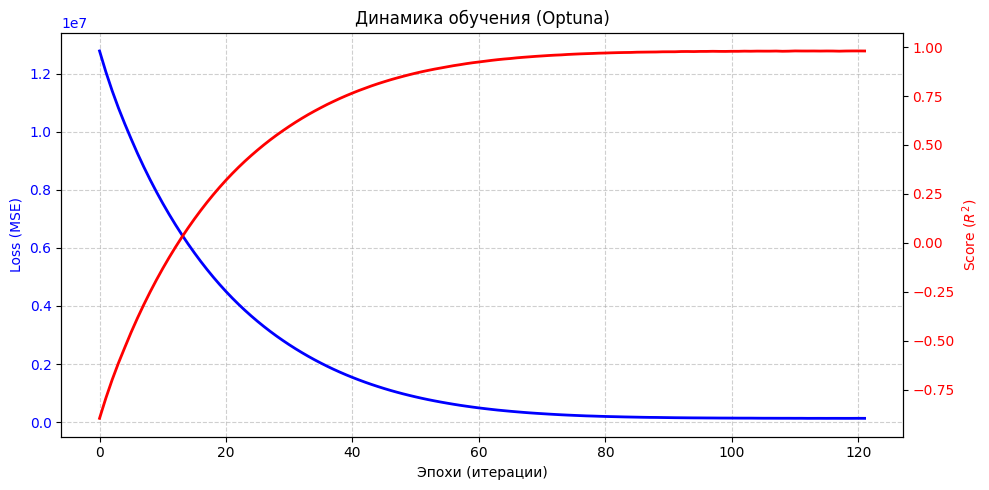

Входных признаков: 4
Скрытые слои: (150, 100)
Количество слоев (всего): 4
Выходной слой: 1
Функция активации: tanh
Оптимизатор: adam


In [24]:
best_params = study.best_params
optuna_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        **best_params,
        random_state=81,
        early_stopping=True,
        max_iter=400,
        n_iter_no_change=10,
        validation_fraction=0.1
    ))
])

base_kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred_optuna = cross_val_predict(optuna_pipeline, x_skb, y, cv=base_kf, n_jobs=-1)
r2_optuna = r2_score(y, y_pred_optuna)
print(f"R^2 = {round(r2_optuna, 4)}")

optuna_pipeline.fit(x_skb, y)
plot_learning_curves(optuna_pipeline, title="Динамика обучения (Optuna)")
print_mlp_architecture(optuna_pipeline)

fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig2 = optuna.visualization.plot_optimization_history(study)
fig2.show()

In [25]:
joblib.dump(optuna_pipeline, 'pipeline_mlp_optuna.pkl')

['pipeline_mlp_optuna.pkl']

In [34]:
results = []

results.append({"Algorithm" : "MLPRegressor Base", "R^2": round(r2_base, 4)})
results.append({"Algorithm" : "MLPRegressor Optuna", "R^2": round(r2_optuna, 4)})

In [35]:
res = pd.DataFrame(results)
res

,Algorithm,R^2
0,MLPRegressor Base,0.9719
1,MLPRegressor Optuna,0.9798


### MLPRegressor с TensorFlow

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x_skb, y, test_size=0.15)

In [16]:
def r_squared(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    total_variance = tf.math.reduce_variance(y_true)
    unexplained_variance = tf.math.reduce_variance(y_true - y_pred)
    
    return 1 - unexplained_variance / (total_variance + tf.keras.backend.epsilon())

def plot_history(history, title):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(history.history['loss'], color='blue', label='Loss (MSE)')
    ax1.set_xlabel('Эпохи (итерации)')
    ax1.set_ylabel('Loss (MSE)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(history.history['r_squared'], color='red', label='Score ($R^2$)')
    ax2.set_ylabel('Score ($R^2$)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(title)
    fig.tight_layout()
    plt.show()

In [44]:
normalizer = tf.keras.layers.Normalization()
normalizer.adapt(x_skb)

base_tensorflow = tf.keras.Sequential(
    [
        normalizer,
        tf.keras.layers.Dense(64, activation="relu", input_shape=x_skb.shape[1]),
        tf.keras.layers.Dense(32, activation="linear"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation="linear"),
    ]
)

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
base_tensorflow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse',
    metrics=[r_squared]
)

history = base_tensorflow.fit(x_train, y_train, epochs=50)
y_pred_base_tf = base_tensorflow.predict(x_test)

r2_base_tf = r2_score(y_test, y_pred_base_tf)
print(f"R^2 = {r2_base_tf}")

Epoch 1/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 1s 379us/step - loss: 6874328.0000 - r_squared: 0.6882
Epoch 2/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 1090575.7500 - r_squared: 0.9130
Epoch 3/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - loss: 1067205.7500 - r_squared: 0.9151
Epoch 4/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 1006229.3750 - r_squared: 0.9195
Epoch 5/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - loss: 1073567.7500 - r_squared: 0.9170
Epoch 6/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - loss: 1064731.1250 - r_squared: 0.9159
Epoch 7/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - loss: 1052282.7500 - r_squared: 0.9169
Epoch 8/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 1040876.0000 - r_squared: 0.9173
Epoch 9/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1081830.2500 - r_squared: 0.9146
Epoch 10/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 1030233.8125 - r_squared: 0.9190
Epoch 11/50
1288/1288 ━━━━━━━

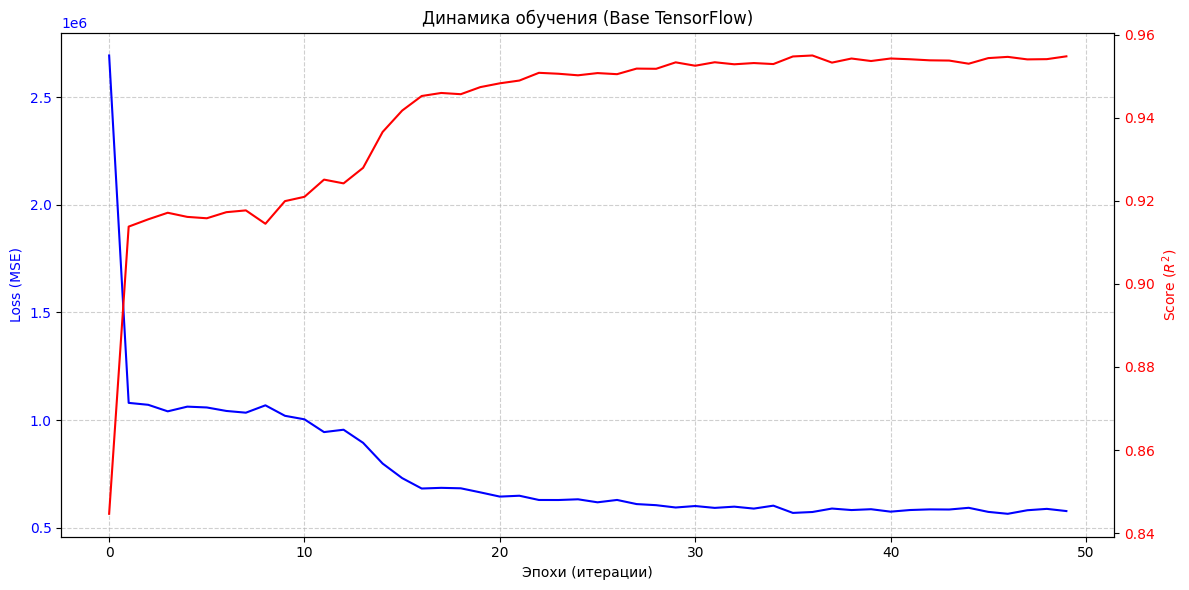

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 4)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,846 (34.56 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 9 (40.00 B)

 Optimizer params: 5,892 (23.02 KB)

In [46]:
plot_history(history=history, title='Динамика обучения (Base TensorFlow)')
base_tensorflow.summary()

In [47]:
base_tensorflow.save('../models/base_tf.keras')

In [ ]:
results.append({"Algorithm" : "TensorFlow Base", "R^2": round(r2_base_tf, 4)})

res = pd.DataFrame(results)
res

,Algorithm,R^2
0,MLPRegressor Base,0.9719
1,MLPRegressor Optuna,0.9798
2,TensorFlow Base,0.9782


### TensorFlow с Ray Tune

In [ ]:
# from ray import tune
# from ray.tune.schedulers import ASHAScheduler

# def train_model(config):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=(x_skb.shape[1],)),
#         tf.keras.layers.Dense(config["l1"], activation="relu"),
#         tf.keras.layers.Dense(config["l2"], activation="relu"),
#         tf.keras.layers.Dropout(config["dropout"]),
#         tf.keras.layers.Dense(1)
#     ])

#     optimizer = tf.keras.optimizers.RMSprop(
#         learning_rate=config["lr"],
#         rho=config["rho"]
#     )

#     model.compile(optimizer=optimizer, loss="mse", metrics=[r_squared])

#     history = model.fit(
#             x_train, y_train,
#             epochs=50,
#             batch_size=config["batch_size"],
#             verbose=0,
#             callbacks=[
#                 tune.integration.keras.TuneReportCallback({
#                     "mean_squared_error": "loss",
#                     "r_squared": "r_squared"
#                 })
#             ]
#         )

# search_space = {
#     "l1": tune.choice([32, 64, 128]),
#     "l2": tune.choice([16, 32, 64]),
#     "lr": tune.loguniform(1e-4, 1e-2),
#     "rho": tune.uniform(0.8, 0.99),
#     "dropout": tune.uniform(0.1, 0.4),
#     "batch_size": tune.choice([16, 32, 64, 128])
# }

In [ ]:
# scheduler = ASHAScheduler(metric=[r_squared], mode="min", max_t=50, grace_period=5)

# analysis = tune.run(
#     train_model,
#     config=search_space,
#     num_samples=10,
#     scheduler=scheduler,
#     stop={"training_iteration": 50}
# )

# best_config = analysis.get_best_config(metric="r_squared", mode="max")
# print("Лучшие параметры:", best_config)

2026-05-05 08:55:02,930	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


2026-05-05 08:55:12,432	ERROR tune_controller.py:1331 -- Trial task failed for trial train_model_d03b3_00001
Traceback (most recent call last):
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/_private/worker.py", line 2961, in get
    values, debugger_breakpoint = worker.get_objects(
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-p

Trial name
train_model_d03b3_00000
train_model_d03b3_00001
train_model_d03b3_00002
train_model_d03b3_00003
train_model_d03b3_00004
train_model_d03b3_00005
train_model_d03b3_00006
train_model_d03b3_00007
train_model_d03b3_00008
train_model_d03b3_00009


2026-05-05 08:55:12,446	ERROR tune_controller.py:1331 -- Trial task failed for trial train_model_d03b3_00004
Traceback (most recent call last):
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/_private/worker.py", line 2961, in get
    values, debugger_breakpoint = worker.get_objects(
  File "/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-p

TuneError: ('Trials did not complete', [train_model_d03b3_00000, train_model_d03b3_00001, train_model_d03b3_00002, train_model_d03b3_00003, train_model_d03b3_00004, train_model_d03b3_00005, train_model_d03b3_00006, train_model_d03b3_00007, train_model_d03b3_00008, train_model_d03b3_00009])

In [ ]:
ray_tensorflow, history_tf = train_model(best_config)
y_pred_ray_tf = ray_tensorflow.predict(x_test)
r2_ray_tf = r2_score(y_test, y_pred_ray_tf)

print(f"R^2 = {r2_base_tf}")
print(analysis.best_result)
plot_history(history=history_tf, title='Динамика обучения TensorFlow Ray Tune')

In [ ]:
# results.append({"Algorithm" : "TensorFlow Ray Tune", "R^2": round(r2_ray_tf, 4)})

# res = pd.DataFrame(results)
# res

In [22]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler
# from ray.tune.integration.keras import TuneReportCallback
from ray.train.tensorflow.keras import ReportCheckpointCallbac

ImportError: cannot import name 'ReportCheckpointCallbac' from 'ray.train.tensorflow.keras' (/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/ray/train/tensorflow/keras.py)

In [ ]:
def ray_trainable(config):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))
    for _ in range(config['n_layers']):
        model.add(layers.Dense(config['units'], activation='relu'))
        model.add(layers.Dropout(config['dropout_rate']))
    model.add(layers.Dense(num_classes, activation='softmax'))

    opt_name = config['optimizer']
    lr = config['learning_rate']
    if opt_name == 'adam':
        optimizer = optimizers.Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        optimizer = optimizers.SGD(learning_rate=lr)
    else:
        optimizer = optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_clf, y_train_clf,
        validation_split=0.2,
        epochs=20,
        batch_size=int(config['batch_size']),
        verbose=0,
        callbacks=[ReportCheckpointCallback()]
    )

search_space = {
    'n_layers': tune.randint(1, 4),
    'units': tune.choice([32, 64, 128, 256]),
    'dropout_rate': tune.uniform(0.0, 0.5),
    'optimizer': tune.choice(['adam', 'sgd', 'rmsprop']),
    'learning_rate': tune.loguniform(1e-4, 1e-2),
    'batch_size': tune.choice([16, 32, 64, 128])
}